In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow: 2.10.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
PROJECT_ROOT = Path("..").resolve()
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"

train_df = pd.read_csv(SPLIT_DIR / "state_farm_train_subject.csv")
val_df = pd.read_csv(SPLIT_DIR / "state_farm_val_subject.csv")
test_df = pd.read_csv(SPLIT_DIR / "state_farm_test_subject.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(train_df.head())

Train: (15899, 6)
Validation: (3439, 6)
Test: (3086, 6)


,subject,classname,img,filepath,file_exists,label
0,p014,c0,img_72495.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
1,p014,c0,img_62101.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
2,p014,c0,img_34774.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
3,p014,c0,img_100312.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
4,p014,c0,img_12279.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0


In [3]:
CLASS_ORDER = [f"c{i}" for i in range(10)]

CLASS_NAMES = {
    "c0": "safe driving",
    "c1": "texting right",
    "c2": "talking on the phone right",
    "c3": "texting left",
    "c4": "talking on the phone left",
    "c5": "operating the radio",
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger",
}

TARGET_NAMES = [f"{class_id} - {CLASS_NAMES[class_id]}" for class_id in CLASS_ORDER]

print(TARGET_NAMES)

['c0 - safe driving', 'c1 - texting right', 'c2 - talking on the phone right', 'c3 - texting left', 'c4 - talking on the phone left', 'c5 - operating the radio', 'c6 - drinking', 'c7 - reaching behind', 'c8 - hair and makeup', 'c9 - talking to passenger']


In [4]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10

AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

In [5]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print("Datasets created successfully.")

Datasets created successfully.


In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.15),
], name="safe_augmentation")


def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


model, base_model = build_mobilenetv2_model(
    input_shape=IMG_SIZE + (3,),
    num_classes=10
)

model.summary()

9406464/9406464 [==============================] - 1s 0us/step
Model: "mobilenetv2_transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 safe_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280) 

In [7]:
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "02_mobilenetv2"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
REPORTS_DIR = RESULTS_DIR / "reports"
CM_DIR = RESULTS_DIR / "confusion_matrices"

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(EXPERIMENT_DIR / "best_mobilenetv2.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [8]:
start_time = time.time()

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

initial_training_time = time.time() - start_time

print("Initial training time minutes:", initial_training_time / 60)

Epoch 1/10
994/994 [==============================] - ETA: 0s - loss: 1.3443 - accuracy: 0.5515
Epoch 1: val_accuracy improved from -inf to 0.56644, saving model to D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2.keras
994/994 [==============================] - 130s 121ms/step - loss: 1.3443 - accuracy: 0.5515 - val_loss: 1.3077 - val_accuracy: 0.5664 - lr: 0.0010
Epoch 2/10
994/994 [==============================] - ETA: 0s - loss: 0.7673 - accuracy: 0.7464
Epoch 2: val_accuracy did not improve from 0.56644
994/994 [==============================] - 109s 109ms/step - loss: 0.7673 - accuracy: 0.7464 - val_loss: 1.3185 - val_accuracy: 0.5473 - lr: 0.0010
Epoch 3/10
994/994 [==============================] - ETA: 0s - loss: 0.6791 - accuracy: 0.7707
Epoch 3: val_accuracy improved from 0.56644 to 0.62256, saving model to D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2.keras
994/994 [==============================] - 109s 110ms/step - loss: 0.6791 - accuracy: 0.7707 -

In [9]:
start_time = time.time()

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

initial_training_time = time.time() - start_time

print("Initial training time minutes:", initial_training_time / 60)

Epoch 1/10
994/994 [==============================] - ETA: 0s - loss: 0.5983 - accuracy: 0.8026
Epoch 1: val_accuracy did not improve from 0.62256
994/994 [==============================] - 111s 112ms/step - loss: 0.5983 - accuracy: 0.8026 - val_loss: 1.1953 - val_accuracy: 0.6072 - lr: 9.0000e-05
Epoch 2/10
994/994 [==============================] - ETA: 0s - loss: 0.5791 - accuracy: 0.8097
Epoch 2: val_accuracy did not improve from 0.62256
994/994 [==============================] - 109s 110ms/step - loss: 0.5791 - accuracy: 0.8097 - val_loss: 1.1726 - val_accuracy: 0.6080 - lr: 9.0000e-05
Epoch 3/10
994/994 [==============================] - ETA: 0s - loss: 0.5805 - accuracy: 0.8091
Epoch 3: val_accuracy did not improve from 0.62256
994/994 [==============================] - 109s 110ms/step - loss: 0.5805 - accuracy: 0.8091 - val_loss: 1.2097 - val_accuracy: 0.5949 - lr: 9.0000e-05
Epoch 4/10
994/994 [==============================] - ETA: 0s - loss: 0.5632 - accuracy: 0.8150
Epoch 4

In [10]:
best_initial_model_path = EXPERIMENT_DIR / "best_mobilenetv2.keras"

model = tf.keras.models.load_model(best_initial_model_path)

print("Loaded best initial MobileNetV2 model from:")
print(best_initial_model_path)

val_loss, val_accuracy = model.evaluate(val_ds)
print("Loaded model validation loss:", val_loss)
print("Loaded model validation accuracy:", val_accuracy)

Loaded best initial MobileNetV2 model from:
D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2.keras
215/215 [==============================] - 5s 19ms/step - loss: 1.1954 - accuracy: 0.6226
Loaded model validation loss: 1.1954407691955566
Loaded model validation accuracy: 0.6225646734237671


In [11]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

0 input_1 InputLayer True
1 safe_augmentation Sequential True
2 tf.math.truediv TFOpLambda True
3 tf.math.subtract TFOpLambda True
4 mobilenetv2_1.00_224 Functional True
5 global_average_pooling2d GlobalAveragePooling2D True
6 dropout Dropout True
7 dense Dense True


In [12]:
# Find the MobileNetV2 base model inside the full model
base_model_layer = None

for layer in model.layers:
    if "mobilenetv2" in layer.name.lower():
        base_model_layer = layer
        break

if base_model_layer is None:
    raise ValueError("Could not find MobileNetV2 base model layer.")

print("Found base model layer:", base_model_layer.name)

# Unfreeze the base model
base_model_layer.trainable = True

# Freeze earlier layers and fine-tune only the last 30 layers
for layer in base_model_layer.layers[:-30]:
    layer.trainable = False

for layer in base_model_layer.layers[-30:]:
    layer.trainable = True

# Important: use a very small learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning setup completed.")
print("Total model layers:", len(model.layers))
print("Base model layers:", len(base_model_layer.layers))

Found base model layer: mobilenetv2_1.00_224
Fine-tuning setup completed.
Total model layers: 8
Base model layers: 154


In [13]:
fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(EXPERIMENT_DIR / "best_mobilenetv2_finetuned.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [14]:
start_time = time.time()

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

fine_tuning_time = time.time() - start_time

print("Fine-tuning time minutes:", fine_tuning_time / 60)

Epoch 1/10
994/994 [==============================] - ETA: 0s - loss: 0.4089 - accuracy: 0.8667
Epoch 1: val_accuracy improved from -inf to 0.71271, saving model to D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2_finetuned.keras
994/994 [==============================] - 123s 118ms/step - loss: 0.4089 - accuracy: 0.8667 - val_loss: 0.8416 - val_accuracy: 0.7127 - lr: 1.0000e-05
Epoch 2/10
994/994 [==============================] - ETA: 0s - loss: 0.2337 - accuracy: 0.9276
Epoch 2: val_accuracy did not improve from 0.71271
994/994 [==============================] - 112s 113ms/step - loss: 0.2337 - accuracy: 0.9276 - val_loss: 0.9868 - val_accuracy: 0.6708 - lr: 1.0000e-05
Epoch 3/10
994/994 [==============================] - ETA: 0s - loss: 0.1601 - accuracy: 0.9527
Epoch 3: val_accuracy improved from 0.71271 to 0.74644, saving model to D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2_finetuned.keras
994/994 [==============================] - 117s 117ms/step - loss:

In [15]:
best_finetuned_model_path = EXPERIMENT_DIR / "best_mobilenetv2_finetuned.keras"

best_model = tf.keras.models.load_model(best_finetuned_model_path)

print("Loaded best fine-tuned MobileNetV2 model from:")
print(best_finetuned_model_path)

Loaded best fine-tuned MobileNetV2 model from:
D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2_finetuned.keras


In [16]:
val_loss, val_accuracy = best_model.evaluate(val_ds)
test_loss, test_accuracy = best_model.evaluate(test_ds)

print("MobileNetV2 Validation Loss:", val_loss)
print("MobileNetV2 Validation Accuracy:", val_accuracy)

print("MobileNetV2 Test Loss:", test_loss)
print("MobileNetV2 Test Accuracy:", test_accuracy)

193/193 [==============================] - 3s 17ms/step - loss: 0.4768 - accuracy: 0.8467
MobileNetV2 Validation Loss: 0.6014394760131836
MobileNetV2 Validation Accuracy: 0.8211689591407776
MobileNetV2 Test Loss: 0.4768403172492981
MobileNetV2 Test Accuracy: 0.8467271327972412


In [17]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

y_prob = best_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

193/193 [==============================] - 4s 18ms/step
True labels shape: (3086,)
Predicted labels shape: (3086,)


In [18]:
report = classification_report(
    y_true,
    y_pred,
    target_names=TARGET_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_path = REPORTS_DIR / "mobilenetv2_classification_report.csv"
report_df.to_csv(report_path)

print("Saved classification report to:")
print(report_path)

,precision,recall,f1-score,support
c0 - safe driving,0.663889,0.756329,0.707101,316.000000
c1 - texting right,0.960177,0.667692,0.787659,325.000000
c2 - talking on the phone right,0.984756,0.955621,0.969970,338.000000
c3 - texting left,0.972136,0.975155,0.973643,322.000000
c4 - talking on the phone left,0.926036,0.907246,0.916545,345.000000
c5 - operating the radio,1.000000,0.923547,0.960254,327.000000
c6 - drinking,0.819209,0.932476,0.872180,311.000000
c7 - reaching behind,0.970588,0.901024,0.934513,293.000000
c8 - hair and makeup,0.631250,0.804781,0.707531,251.000000
c9 - talking to passenger,0.566540,0.577519,0.571977,258.000000


Saved classification report to:
D:\MSC_PROJECT\results\reports\mobilenetv2_classification_report.csv


In [19]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=TARGET_NAMES,
    columns=TARGET_NAMES
)

display(cm_df)

cm_csv_path = CM_DIR / "mobilenetv2_confusion_matrix.csv"
cm_df.to_csv(cm_csv_path)

print("Saved confusion matrix CSV to:")
print(cm_csv_path)

,c0 - safe driving,c1 - texting right,c2 - talking on the phone right,c3 - texting left,c4 - talking on the phone left,c5 - operating the radio,c6 - drinking,c7 - reaching behind,c8 - hair and makeup,c9 - talking to passenger
c0 - safe driving,239,5,1,0,0,0,0,0,3,68
c1 - texting right,8,217,2,5,0,0,43,2,27,21
c2 - talking on the phone right,0,1,323,0,0,0,12,1,1,0
c3 - texting left,3,1,0,314,0,0,0,0,4,0
c4 - talking on the phone left,2,0,1,4,313,0,5,0,20,0
c5 - operating the radio,11,0,0,0,0,302,0,1,1,12
c6 - drinking,1,0,0,0,0,0,290,0,20,0
c7 - reaching behind,23,0,0,0,0,0,0,264,2,4
c8 - hair and makeup,7,1,1,0,25,0,4,2,202,9
c9 - talking to passenger,66,1,0,0,0,0,0,2,40,149


Saved confusion matrix CSV to:
D:\MSC_PROJECT\results\confusion_matrices\mobilenetv2_confusion_matrix.csv


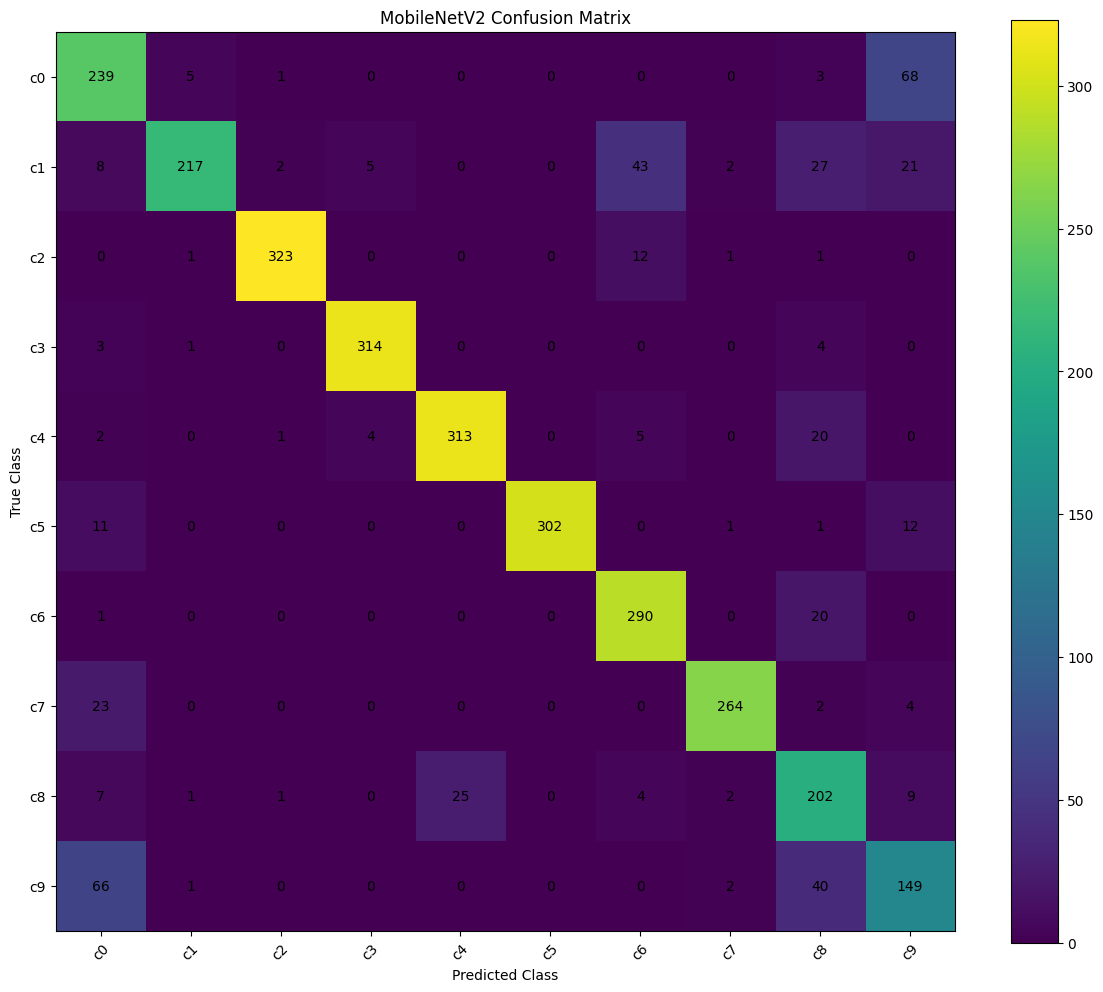

Saved confusion matrix image to:
D:\MSC_PROJECT\results\confusion_matrices\mobilenetv2_confusion_matrix.png


In [20]:
plt.figure(figsize=(12, 10))

plt.imshow(cm)
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(10), CLASS_ORDER, rotation=45)
plt.yticks(range(10), CLASS_ORDER)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_png_path = CM_DIR / "mobilenetv2_confusion_matrix.png"
plt.savefig(cm_png_path, dpi=300)
plt.show()

print("Saved confusion matrix image to:")
print(cm_png_path)

In [21]:
mobilenetv2_summary = {
    "model_name": "mobilenetv2_finetuned",
    "image_size": str(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "initial_epochs": INITIAL_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "best_initial_validation_accuracy": 0.6225646734237671,
    "best_finetuned_validation_accuracy": float(val_accuracy),
    "final_test_accuracy": float(test_accuracy),
    "final_test_loss": float(test_loss),
    "initial_training_time_minutes": initial_training_time / 60,
    "fine_tuning_time_minutes": fine_tuning_time / 60,
    "model_path": str(best_finetuned_model_path)
}

mobilenetv2_summary_df = pd.DataFrame([mobilenetv2_summary])

display(mobilenetv2_summary_df)

summary_path = REPORTS_DIR / "mobilenetv2_summary.csv"
mobilenetv2_summary_df.to_csv(summary_path, index=False)

print("Saved MobileNetV2 summary to:")
print(summary_path)

,model_name,image_size,batch_size,initial_epochs,fine_tune_epochs,best_initial_validation_accuracy,best_finetuned_validation_accuracy,final_test_accuracy,final_test_loss,initial_training_time_minutes,fine_tuning_time_minutes,model_path
0,mobilenetv2_finetuned,"(224, 224)",16,10,10,0.622565,0.821169,0.846727,0.47684,13.033911,18.996937,D:\MSC_PROJECT\experiments\02_mobilenetv2\best...


Saved MobileNetV2 summary to:
D:\MSC_PROJECT\results\reports\mobilenetv2_summary.csv


# EfficientNet-B0 Transfer Learning

In [26]:
def build_efficientnetb0_model(input_shape=(224, 224, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    # EfficientNet has its own preprocessing inside the model in many Keras versions,
    # but using preprocess_input keeps the workflow explicit.
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="efficientnetb0_transfer")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


model, base_model = build_efficientnetb0_model(
    input_shape=IMG_SIZE + (3,),
    num_classes=10
)

model.summary()

Model: "efficientnetb0_transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 safe_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 10)    

In [27]:
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "03_efficientnet_b0"

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

efficientnet_weights_path = EXPERIMENT_DIR / "best_efficientnetb0.weights.h5"

efficientnet_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(efficientnet_weights_path),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("EfficientNet-B0 experiment folder:", EXPERIMENT_DIR)
print("Weights will be saved to:", efficientnet_weights_path)

EfficientNet-B0 experiment folder: D:\MSC_PROJECT\experiments\03_efficientnet_b0
Weights will be saved to: D:\MSC_PROJECT\experiments\03_efficientnet_b0\best_efficientnetb0.weights.h5


In [28]:
start_time = time.time()

history_eff_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=efficientnet_callbacks
)

efficientnet_initial_training_time = time.time() - start_time

print("EfficientNet-B0 initial training time minutes:", efficientnet_initial_training_time / 60)

Epoch 1/10
994/994 [==============================] - ETA: 0s - loss: 1.2439 - accuracy: 0.6305
Epoch 1: val_accuracy improved from -inf to 0.53998, saving model to D:\MSC_PROJECT\experiments\03_efficientnet_b0\best_efficientnetb0.weights.h5
994/994 [==============================] - 126s 119ms/step - loss: 1.2439 - accuracy: 0.6305 - val_loss: 1.4011 - val_accuracy: 0.5400 - lr: 0.0010
Epoch 2/10
994/994 [==============================] - ETA: 0s - loss: 0.6833 - accuracy: 0.8109
Epoch 2: val_accuracy improved from 0.53998 to 0.56092, saving model to D:\MSC_PROJECT\experiments\03_efficientnet_b0\best_efficientnetb0.weights.h5
994/994 [==============================] - 126s 127ms/step - loss: 0.6833 - accuracy: 0.8109 - val_loss: 1.3814 - val_accuracy: 0.5609 - lr: 0.0010
Epoch 3/10
994/994 [==============================] - ETA: 0s - loss: 0.5477 - accuracy: 0.8428
Epoch 3: val_accuracy improved from 0.56092 to 0.59581, saving model to D:\MSC_PROJECT\experiments\03_efficientnet_b0\bes

In [29]:
efficientnet_weights_path = EXPERIMENT_DIR / "best_efficientnetb0.weights.h5"

model, base_model = build_efficientnetb0_model(
    input_shape=IMG_SIZE + (3,),
    num_classes=10
)

model.load_weights(efficientnet_weights_path)

print("Loaded best EfficientNet-B0 initial weights from:")
print(efficientnet_weights_path)

val_loss, val_accuracy = model.evaluate(val_ds)

print("Loaded EfficientNet-B0 validation loss:", val_loss)
print("Loaded EfficientNet-B0 validation accuracy:", val_accuracy)

Loaded best EfficientNet-B0 initial weights from:
D:\MSC_PROJECT\experiments\03_efficientnet_b0\best_efficientnetb0.weights.h5
215/215 [==============================] - 8s 27ms/step - loss: 1.2653 - accuracy: 0.6083
Loaded EfficientNet-B0 validation loss: 1.265334129333496
Loaded EfficientNet-B0 validation accuracy: 0.6083163619041443


In [30]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

0 input_7 InputLayer True
1 safe_augmentation Sequential True
2 efficientnetb0 Functional False
3 global_average_pooling2d_3 GlobalAveragePooling2D True
4 dropout_3 Dropout True
5 dense_3 Dense True


In [31]:
base_model_layer = None

for layer in model.layers:
    if "efficientnet" in layer.name.lower():
        base_model_layer = layer
        break

if base_model_layer is None:
    raise ValueError("Could not find EfficientNet base model layer.")

print("Found base model layer:", base_model_layer.name)

base_model_layer.trainable = True

# Fine-tune only the last 30 layers
for layer in base_model_layer.layers[:-30]:
    layer.trainable = False

for layer in base_model_layer.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNet-B0 fine-tuning setup completed.")
print("Base model layers:", len(base_model_layer.layers))

Found base model layer: efficientnetb0
EfficientNet-B0 fine-tuning setup completed.
Base model layers: 238


In [32]:
efficientnet_finetuned_weights_path = EXPERIMENT_DIR / "best_efficientnetb0_finetuned.weights.h5"

efficientnet_finetune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(efficientnet_finetuned_weights_path),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Fine-tuned weights will be saved to:")
print(efficientnet_finetuned_weights_path)

Fine-tuned weights will be saved to:
D:\MSC_PROJECT\experiments\03_efficientnet_b0\best_efficientnetb0_finetuned.weights.h5


In [33]:
start_time = time.time()

history_eff_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=efficientnet_finetune_callbacks
)

efficientnet_fine_tuning_time = time.time() - start_time

print("EfficientNet-B0 fine-tuning time minutes:", efficientnet_fine_tuning_time / 60)

Epoch 1/10
994/994 [==============================] - ETA: 0s - loss: 0.3511 - accuracy: 0.8972
Epoch 1: val_accuracy improved from -inf to 0.62693, saving model to D:\MSC_PROJECT\experiments\03_efficientnet_b0\best_efficientnetb0_finetuned.weights.h5
994/994 [==============================] - 131s 124ms/step - loss: 0.3511 - accuracy: 0.8972 - val_loss: 1.2700 - val_accuracy: 0.6269 - lr: 1.0000e-05
Epoch 2/10
994/994 [==============================] - ETA: 0s - loss: 0.2561 - accuracy: 0.9268
Epoch 2: val_accuracy improved from 0.62693 to 0.64554, saving model to D:\MSC_PROJECT\experiments\03_efficientnet_b0\best_efficientnetb0_finetuned.weights.h5
994/994 [==============================] - 120s 121ms/step - loss: 0.2561 - accuracy: 0.9268 - val_loss: 1.2313 - val_accuracy: 0.6455 - lr: 1.0000e-05
Epoch 3/10
994/994 [==============================] - ETA: 0s - loss: 0.2070 - accuracy: 0.9402
Epoch 3: val_accuracy improved from 0.64554 to 0.65048, saving model to D:\MSC_PROJECT\experi

In [35]:
best_eff_model = model

print("Using current fine-tuned EfficientNet-B0 model for evaluation.")

val_loss, val_accuracy = best_eff_model.evaluate(val_ds)
test_loss, test_accuracy = best_eff_model.evaluate(test_ds)

print("EfficientNet-B0 Validation Loss:", val_loss)
print("EfficientNet-B0 Validation Accuracy:", val_accuracy)

print("EfficientNet-B0 Test Loss:", test_loss)
print("EfficientNet-B0 Test Accuracy:", test_accuracy)

Using current fine-tuned EfficientNet-B0 model for evaluation.
193/193 [==============================] - 7s 35ms/step - loss: 0.5438 - accuracy: 0.8247
EfficientNet-B0 Validation Loss: 0.984327495098114
EfficientNet-B0 Validation Accuracy: 0.7223029732704163
EfficientNet-B0 Test Loss: 0.5437890887260437
EfficientNet-B0 Test Accuracy: 0.8246921300888062


In [36]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

y_prob = best_eff_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=TARGET_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_path = REPORTS_DIR / "efficientnetb0_classification_report.csv"
report_df.to_csv(report_path)

print("Saved EfficientNet-B0 classification report to:")
print(report_path)

193/193 [==============================] - 6s 28ms/step


,precision,recall,f1-score,support
c0 - safe driving,0.707246,0.772152,0.738275,316.000000
c1 - texting right,0.970803,0.818462,0.888147,325.000000
c2 - talking on the phone right,0.972973,0.958580,0.965723,338.000000
c3 - texting left,0.946903,0.996894,0.971256,322.000000
c4 - talking on the phone left,0.890208,0.869565,0.879765,345.000000
c5 - operating the radio,0.989011,0.825688,0.900000,327.000000
c6 - drinking,0.893130,0.752412,0.816754,311.000000
c7 - reaching behind,0.821429,0.941980,0.877583,293.000000
c8 - hair and makeup,0.502688,0.745020,0.600321,251.000000
c9 - talking to passenger,0.572093,0.476744,0.520085,258.000000


Saved EfficientNet-B0 classification report to:
D:\MSC_PROJECT\results\reports\efficientnetb0_classification_report.csv


In [37]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=TARGET_NAMES,
    columns=TARGET_NAMES
)

display(cm_df)

cm_csv_path = CM_DIR / "efficientnetb0_confusion_matrix.csv"
cm_df.to_csv(cm_csv_path)

print("Saved EfficientNet-B0 confusion matrix CSV to:")
print(cm_csv_path)

,c0 - safe driving,c1 - texting right,c2 - talking on the phone right,c3 - texting left,c4 - talking on the phone left,c5 - operating the radio,c6 - drinking,c7 - reaching behind,c8 - hair and makeup,c9 - talking to passenger
c0 - safe driving,244,1,0,1,2,0,0,0,10,58
c1 - texting right,3,266,2,0,0,0,7,0,47,0
c2 - talking on the phone right,0,0,324,0,0,0,13,0,1,0
c3 - texting left,0,1,0,321,0,0,0,0,0,0
c4 - talking on the phone left,7,0,0,16,300,1,2,1,17,1
c5 - operating the radio,6,0,1,0,1,270,0,5,19,25
c6 - drinking,0,6,0,0,1,0,234,0,70,0
c7 - reaching behind,0,0,0,0,0,1,0,276,13,3
c8 - hair and makeup,7,0,6,1,33,0,6,6,187,5
c9 - talking to passenger,78,0,0,0,0,1,0,48,8,123


Saved EfficientNet-B0 confusion matrix CSV to:
D:\MSC_PROJECT\results\confusion_matrices\efficientnetb0_confusion_matrix.csv


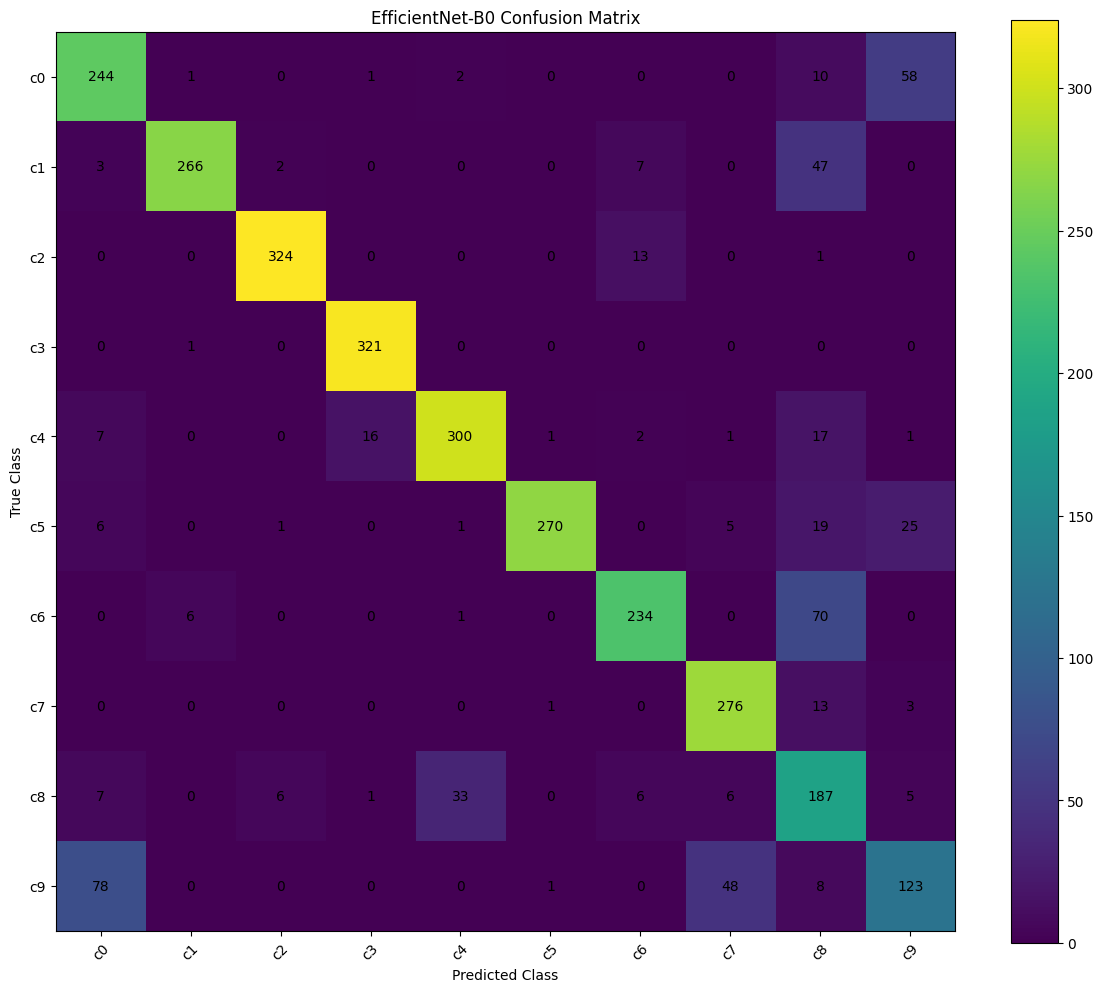

Saved EfficientNet-B0 confusion matrix image to:
D:\MSC_PROJECT\results\confusion_matrices\efficientnetb0_confusion_matrix.png


In [38]:
plt.figure(figsize=(12, 10))

plt.imshow(cm)
plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(10), CLASS_ORDER, rotation=45)
plt.yticks(range(10), CLASS_ORDER)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_png_path = CM_DIR / "efficientnetb0_confusion_matrix.png"
plt.savefig(cm_png_path, dpi=300)
plt.show()

print("Saved EfficientNet-B0 confusion matrix image to:")
print(cm_png_path)

In [39]:
efficientnetb0_summary = {
    "model_name": "efficientnetb0_finetuned",
    "image_size": str(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "initial_epochs": INITIAL_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "best_initial_validation_accuracy": float(max(history_eff_initial.history["val_accuracy"])),
    "best_finetuned_validation_accuracy": float(val_accuracy),
    "final_test_accuracy": float(test_accuracy),
    "final_test_loss": float(test_loss),
    "initial_training_time_minutes": efficientnet_initial_training_time / 60,
    "fine_tuning_time_minutes": efficientnet_fine_tuning_time / 60,
    "weights_path": str(efficientnet_finetuned_weights_path)
}

efficientnetb0_summary_df = pd.DataFrame([efficientnetb0_summary])

display(efficientnetb0_summary_df)

summary_path = REPORTS_DIR / "efficientnetb0_summary.csv"
efficientnetb0_summary_df.to_csv(summary_path, index=False)

print("Saved EfficientNet-B0 summary to:")
print(summary_path)

,model_name,image_size,batch_size,initial_epochs,fine_tune_epochs,best_initial_validation_accuracy,best_finetuned_validation_accuracy,final_test_accuracy,final_test_loss,initial_training_time_minutes,fine_tuning_time_minutes,weights_path
0,efficientnetb0_finetuned,"(224, 224)",16,10,10,0.608316,0.722303,0.824692,0.543789,18.401494,19.168153,D:\MSC_PROJECT\experiments\03_efficientnet_b0\...


Saved EfficientNet-B0 summary to:
D:\MSC_PROJECT\results\reports\efficientnetb0_summary.csv


In [40]:
savedmodel_path = PROJECT_ROOT / "experiments" / "03_efficientnet_b0" / "efficientnetb0_finetuned_savedmodel"

best_eff_model.save(savedmodel_path, save_format="tf")

print("Saved EfficientNet-B0 SavedModel to:")
print(savedmodel_path)

INFO:tensorflow:Assets written to: D:\MSC_PROJECT\experiments\03_efficientnet_b0\efficientnetb0_finetuned_savedmodel\assets


INFO:tensorflow:Assets written to: D:\MSC_PROJECT\experiments\03_efficientnet_b0\efficientnetb0_finetuned_savedmodel\assets


TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

# Single Image Testing

In [41]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

PROJECT_ROOT = Path("..").resolve()

baseline_model_path = PROJECT_ROOT / "experiments" / "01_baseline_cnn" / "best_baseline_cnn.keras"
mobilenet_model_path = PROJECT_ROOT / "experiments" / "02_mobilenetv2" / "best_mobilenetv2_finetuned.keras"

baseline_model = tf.keras.models.load_model(baseline_model_path)
mobilenet_model = tf.keras.models.load_model(mobilenet_model_path)

print("Loaded Baseline CNN:", baseline_model_path)
print("Loaded MobileNetV2:", mobilenet_model_path)

# EfficientNet-B0 should already exist in this notebook as best_eff_model
try:
    efficientnet_model = best_eff_model
    print("EfficientNet-B0 model found in memory.")
except NameError:
    efficientnet_model = None
    print("EfficientNet-B0 model is not in memory. Use this only if Notebook 04 was not restarted.")

Loaded Baseline CNN: D:\MSC_PROJECT\experiments\01_baseline_cnn\best_baseline_cnn.keras
Loaded MobileNetV2: D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2_finetuned.keras
EfficientNet-B0 model found in memory.


In [42]:
CLASS_ORDER = [f"c{i}" for i in range(10)]

CLASS_NAMES = {
    "c0": "safe driving",
    "c1": "texting right",
    "c2": "talking on the phone right",
    "c3": "texting left",
    "c4": "talking on the phone left",
    "c5": "operating the radio",
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger",
}

IMG_SIZE = (224, 224)

In [43]:
def load_single_image(image_path, img_size=(224, 224)):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    image = tf.io.read_file(str(image_path))
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)

    # Add batch dimension: (224, 224, 3) -> (1, 224, 224, 3)
    image_batch = tf.expand_dims(image, axis=0)

    return image_batch


def predict_single_image(model, image_path, model_name):
    image_batch = load_single_image(image_path, IMG_SIZE)

    probabilities = model.predict(image_batch, verbose=0)[0]

    predicted_index = int(np.argmax(probabilities))
    predicted_class = CLASS_ORDER[predicted_index]
    predicted_label = CLASS_NAMES[predicted_class]
    confidence = float(probabilities[predicted_index])

    result = {
        "model": model_name,
        "predicted_class": predicted_class,
        "predicted_label": predicted_label,
        "confidence": confidence
    }

    return result, probabilities

Testing image:
D:\MSC_PROJECT\state-farm-distracted-driver-detection\imgs\train\c0\img_44733.jpg
Image exists: True


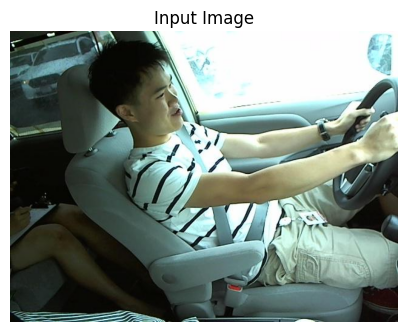

In [44]:
DATA_ROOT = PROJECT_ROOT / "state-farm-distracted-driver-detection"
test_image_path = DATA_ROOT / "imgs" / "train" / "c0" / "img_44733.jpg"

print("Testing image:")
print(test_image_path)
print("Image exists:", test_image_path.exists())

img = Image.open(test_image_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

In [45]:
all_results = []

baseline_result, baseline_probs = predict_single_image(
    baseline_model,
    test_image_path,
    "Baseline CNN"
)
all_results.append(baseline_result)

mobilenet_result, mobilenet_probs = predict_single_image(
    mobilenet_model,
    test_image_path,
    "MobileNetV2"
)
all_results.append(mobilenet_result)

if efficientnet_model is not None:
    efficientnet_result, efficientnet_probs = predict_single_image(
        efficientnet_model,
        test_image_path,
        "EfficientNet-B0"
    )
    all_results.append(efficientnet_result)

results_df = pd.DataFrame(all_results)
display(results_df)

,model,predicted_class,predicted_label,confidence
0,Baseline CNN,c0,safe driving,0.815094
1,MobileNetV2,c0,safe driving,0.678266
2,EfficientNet-B0,c0,safe driving,0.931367


,class_id,class_name,probability
0,c0,safe driving,6.782660e-01
4,c4,talking on the phone left,1.264533e-01
8,c8,hair and makeup,1.063749e-01
9,c9,talking to passenger,6.146951e-02
5,c5,operating the radio,1.349401e-02
3,c3,texting left,1.169266e-02
6,c6,drinking,1.534000e-03
2,c2,talking on the phone right,5.630921e-04
7,c7,reaching behind,1.520312e-04
1,c1,texting right,5.233765e-07


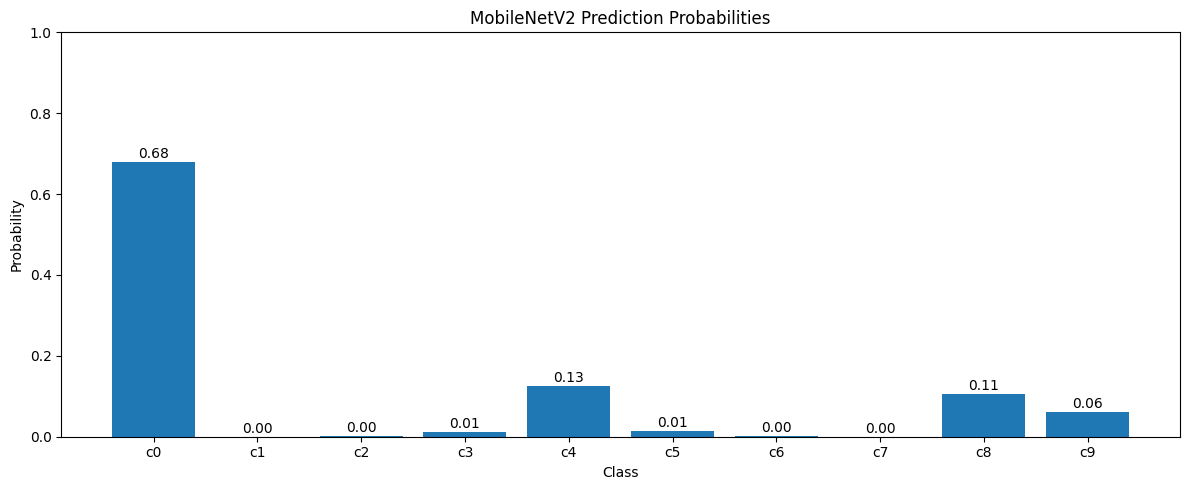

In [46]:
prob_df = pd.DataFrame({
    "class_id": CLASS_ORDER,
    "class_name": [CLASS_NAMES[c] for c in CLASS_ORDER],
    "probability": mobilenet_probs
})

display(prob_df.sort_values("probability", ascending=False))

plt.figure(figsize=(12, 5))
plt.bar(prob_df["class_id"], prob_df["probability"])

plt.title("MobileNetV2 Prediction Probabilities")
plt.xlabel("Class")
plt.ylabel("Probability")
plt.ylim(0, 1)

for i, prob in enumerate(prob_df["probability"]):
    plt.text(i, prob + 0.01, f"{prob:.2f}", ha="center")

plt.tight_layout()
plt.show()

Real image path:
D:\MSC_PROJECT\real_test_images\my_test_1.jpeg
Exists: True


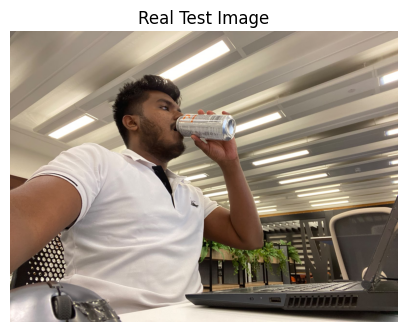

In [52]:
real_image_path = PROJECT_ROOT / "real_test_images" / "my_test_1.jpeg"

print("Real image path:")
print(real_image_path)
print("Exists:", real_image_path.exists())

img = Image.open(real_image_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Real Test Image")
plt.axis("off")
plt.show()

In [53]:
real_results = []

baseline_result, baseline_probs = predict_single_image(
    baseline_model,
    real_image_path,
    "Baseline CNN"
)
real_results.append(baseline_result)

mobilenet_result, mobilenet_probs = predict_single_image(
    mobilenet_model,
    real_image_path,
    "MobileNetV2"
)
real_results.append(mobilenet_result)

if efficientnet_model is not None:
    efficientnet_result, efficientnet_probs = predict_single_image(
        efficientnet_model,
        real_image_path,
        "EfficientNet-B0"
    )
    real_results.append(efficientnet_result)

real_results_df = pd.DataFrame(real_results)
display(real_results_df)

,model,predicted_class,predicted_label,confidence
0,Baseline CNN,c5,operating the radio,1.000000
1,MobileNetV2,c7,reaching behind,0.467935
2,EfficientNet-B0,c6,drinking,0.646958


Real image path:
D:\MSC_PROJECT\real_test_images\my_test_2.jpeg
Exists: True


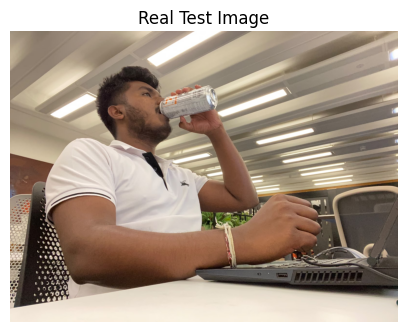

In [54]:
real_image_path = PROJECT_ROOT / "real_test_images" / "my_test_2.jpeg"

print("Real image path:")
print(real_image_path)
print("Exists:", real_image_path.exists())

img = Image.open(real_image_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Real Test Image")
plt.axis("off")
plt.show()

In [55]:
real_results = []

baseline_result, baseline_probs = predict_single_image(
    baseline_model,
    real_image_path,
    "Baseline CNN"
)
real_results.append(baseline_result)

mobilenet_result, mobilenet_probs = predict_single_image(
    mobilenet_model,
    real_image_path,
    "MobileNetV2"
)
real_results.append(mobilenet_result)

if efficientnet_model is not None:
    efficientnet_result, efficientnet_probs = predict_single_image(
        efficientnet_model,
        real_image_path,
        "EfficientNet-B0"
    )
    real_results.append(efficientnet_result)

real_results_df = pd.DataFrame(real_results)
display(real_results_df)

,model,predicted_class,predicted_label,confidence
0,Baseline CNN,c5,operating the radio,1.000000
1,MobileNetV2,c6,drinking,0.644967
2,EfficientNet-B0,c5,operating the radio,0.432209


Real image path:
D:\MSC_PROJECT\real_test_images\my_test_3.jpeg
Exists: True


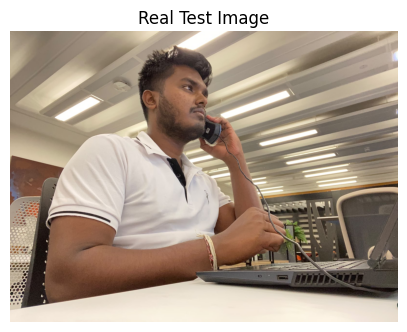

In [56]:
real_image_path = PROJECT_ROOT / "real_test_images" / "my_test_3.jpeg"

print("Real image path:")
print(real_image_path)
print("Exists:", real_image_path.exists())

img = Image.open(real_image_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Real Test Image")
plt.axis("off")
plt.show()

In [58]:
real_results = []

baseline_result, baseline_probs = predict_single_image(
    baseline_model,
    real_image_path,
    "Baseline CNN"
)
real_results.append(baseline_result)

mobilenet_result, mobilenet_probs = predict_single_image(
    mobilenet_model,
    real_image_path,
    "MobileNetV2"
)
real_results.append(mobilenet_result)

if efficientnet_model is not None:
    efficientnet_result, efficientnet_probs = predict_single_image(
        efficientnet_model,
        real_image_path,
        "EfficientNet-B0"
    )
    real_results.append(efficientnet_result)

real_results_df = pd.DataFrame(real_results)
display(real_results_df)

,model,predicted_class,predicted_label,confidence
0,Baseline CNN,c5,operating the radio,1.000000
1,MobileNetV2,c8,hair and makeup,0.905836
2,EfficientNet-B0,c4,talking on the phone left,0.583384


In [59]:
real_test_summary = pd.DataFrame([
    {
        "image": "state_farm_c0_img_44733",
        "source": "State Farm dataset",
        "true_label": "c0 - safe driving",
        "baseline_prediction": "c0 - safe driving",
        "mobilenet_prediction": "c0 - safe driving",
        "efficientnet_prediction": "c0 - safe driving",
        "observation": "All models predicted correctly on dataset-style image."
    },
    {
        "image": "my_test_1",
        "source": "Own real image",
        "true_label": "c6 - drinking",
        "baseline_prediction": "c5 - operating the radio",
        "mobilenet_prediction": "c7 - reaching behind",
        "efficientnet_prediction": "c6 - drinking",
        "observation": "EfficientNet-B0 correctly identified drinking; other models were affected by out-of-domain background."
    },
    {
        "image": "my_test_2",
        "source": "Own real image",
        "true_label": "c6 - drinking",
        "baseline_prediction": "c5 - operating the radio",
        "mobilenet_prediction": "c6 - drinking",
        "efficientnet_prediction": "c5 - operating the radio",
        "observation": "MobileNetV2 correctly identified drinking when the hand and can were more visible."
    },
    {
        "image": "my_test_3",
        "source": "Own real image",
        "true_label": "c4 - talking on the phone left",
        "baseline_prediction": "c5 - operating the radio",
        "mobilenet_prediction": "c8 - hair and makeup",
        "efficientnet_prediction": "c4 - talking on the phone left",
        "observation": "EfficientNet-B0 correctly identified phone use with the left hand."
    },
])

display(real_test_summary)

real_test_summary_path = PROJECT_ROOT / "results" / "tables" / "qualitative_real_image_test_summary.csv"
real_test_summary.to_csv(real_test_summary_path, index=False)

print("Saved qualitative real-image test summary to:")
print(real_test_summary_path)

,image,source,true_label,baseline_prediction,mobilenet_prediction,efficientnet_prediction,observation
0,state_farm_c0_img_44733,State Farm dataset,c0 - safe driving,c0 - safe driving,c0 - safe driving,c0 - safe driving,All models predicted correctly on dataset-styl...
1,my_test_1,Own real image,c6 - drinking,c5 - operating the radio,c7 - reaching behind,c6 - drinking,EfficientNet-B0 correctly identified drinking;...
2,my_test_2,Own real image,c6 - drinking,c5 - operating the radio,c6 - drinking,c5 - operating the radio,MobileNetV2 correctly identified drinking when...
3,my_test_3,Own real image,c4 - talking on the phone left,c5 - operating the radio,c8 - hair and makeup,c4 - talking on the phone left,EfficientNet-B0 correctly identified phone use...


Saved qualitative real-image test summary to:
D:\MSC_PROJECT\results\tables\qualitative_real_image_test_summary.csv
